# Edward Tufte’s principles in practice

This notebook demonstrates core ideas from *[The Visual Display of Quantitative Information](https://www.edwardtufte.com/tufte/books_vdqi)* and related work: **maximize the data–ink ratio**, **remove chartjunk**, use **small multiples** and **sparklines**, and **integrate words, numbers, and images** so the graphic carries the argument.

Synthetic data keeps the focus on visual design, not domain interpretation.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

rng = np.random.default_rng(42)


def tufte_axes(ax, show_grid=False):
    """Minimal frame: emphasize data, not decoration (Tufte-style defaults)."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(axis="both", which="both", length=3, width=0.6, labelsize=9)
    if show_grid:
        ax.grid(True, linestyle="-", linewidth=0.35, alpha=0.35)
        ax.set_axisbelow(True)
    return ax

## 1. Maximize data–ink; remove chartjunk

**Data–ink** is ink that encodes data. **Non-data-ink** is everything else. Tufte argues we should remove ink that does not help the reader see the data—heavy frames, gratuitous 3D, moiré fills, ornamental grids, and redundant ticks often fall in this bucket.

Below: the same monthly series twice—once “busy,” once pared down so **the line is the story**.

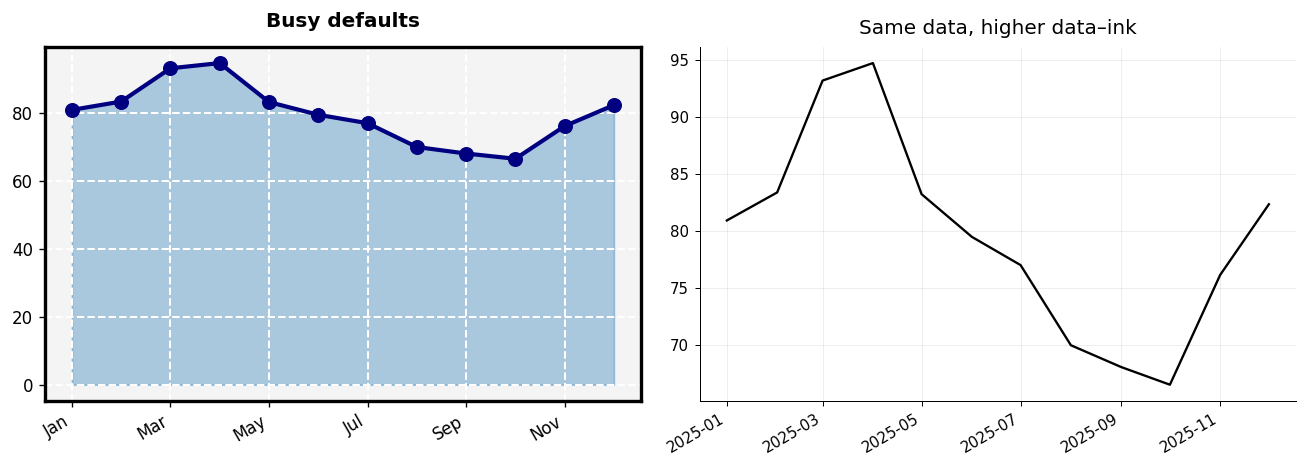

In [2]:
months = pd.date_range("2025-01-01", periods=12, freq="MS")
sales = 80 + 12 * np.sin(np.linspace(0, 2 * np.pi, 12)) + rng.normal(0, 3, 12)

fig, (ax_bad, ax_good) = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

# Chartjunk-heavy
ax_bad.set_facecolor("#f4f4f4")
ax_bad.grid(True, linestyle="--", linewidth=1.2, color="white")
ax_bad.fill_between(range(len(months)), sales, alpha=0.35, color="tab:blue")
ax_bad.plot(sales, color="navy", linewidth=2.5, marker="o", markersize=8)
for spine in ax_bad.spines.values():
    spine.set_linewidth(2)
ax_bad.set_title("Busy defaults", fontsize=12, fontweight="bold", pad=12)
ax_bad.set_xticks(range(0, 12, 2))
ax_bad.set_xticklabels([m.strftime("%b") for m in months[::2]])

# Tufte-lean: thin frame, one clear line, light grid optional
tufte_axes(ax_good, show_grid=True)
ax_good.plot(months, sales, color="black", linewidth=1.4, marker="", zorder=3)
ax_good.set_title("Same data, higher data–ink", fontsize=12, pad=8)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 2. Small multiples: repeat structure, vary only what changes

When comparing groups over the same scale, **small multiples** (a grid of the same chart type) let the eye compare **shape** without decoding new legends or axes every time.

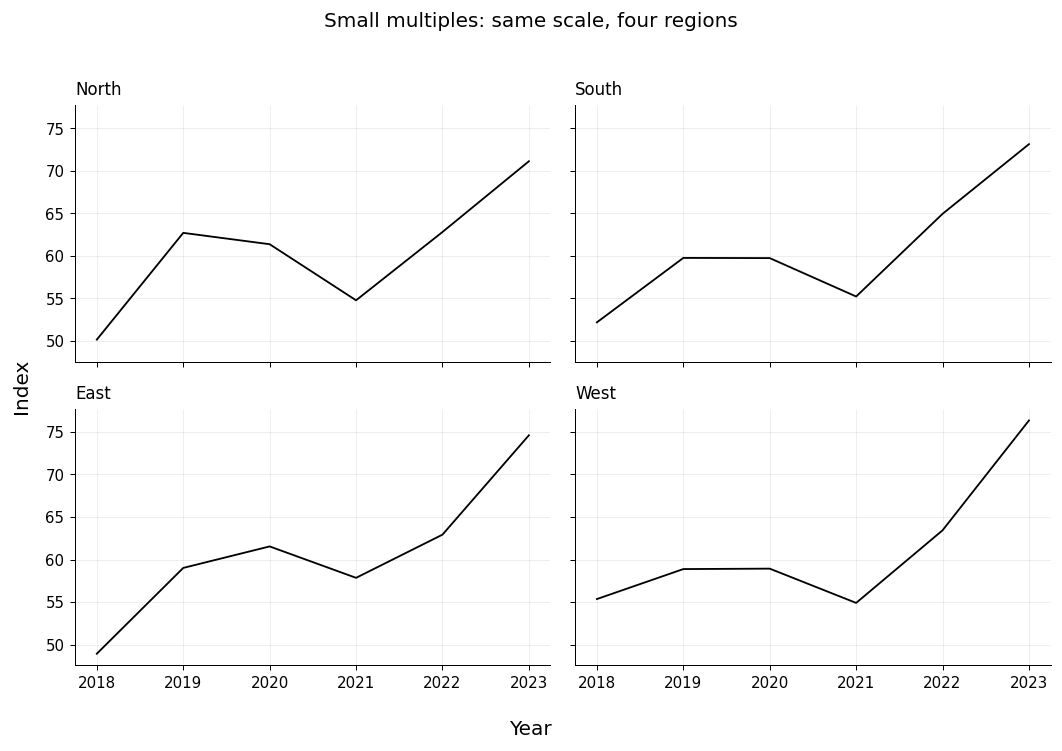

In [3]:
regions = ["North", "South", "East", "West"]
t = np.arange(2018, 2024)
base = np.linspace(50, 70, len(t))

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True, dpi=120)
axes = axes.ravel()

for ax, region in zip(axes, regions):
    noise = rng.normal(0, 2.5, len(t))
    y = base + 6 * np.sin(np.linspace(0, 2.2 * np.pi, len(t))) + noise
    tufte_axes(ax, show_grid=True)
    ax.plot(t, y, color="black", linewidth=1.1)
    ax.set_title(region, loc="left", fontsize=10, fontweight="normal")

fig.suptitle("Small multiples: same scale, four regions", fontsize=12, y=1.02)
fig.supxlabel("Year")
fig.supylabel("Index")
plt.tight_layout()
plt.show()

## 3. Sparklines: word-sized, high-resolution graphics (not that good here)

**Sparklines** are dense little line charts meant to sit **inline with text or tables**—trend at a glance, minimal axes. Tufte emphasized *resolution*: many data points in a small space.

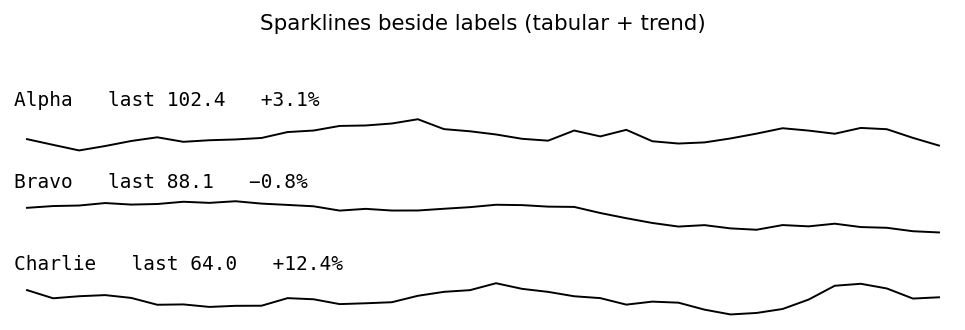

In [4]:
def sparkline(ax, y, **kwargs):
    ax.plot(np.arange(len(y)), y, color="black", linewidth=1, **kwargs)
    ax.axis("off")
    ymin, ymax = y.min(), y.max()
    pad = 0.05 * (ymax - ymin + 1e-9)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_xlim(-0.5, len(y) - 0.5)


series = pd.DataFrame(
    {
        "Product": ["Alpha", "Bravo", "Charlie"],
        "Last": [102.4, 88.1, 64.0],
        "Δ%": ["+3.1%", "−0.8%", "+12.4%"],
    }
)

histories = []
for i in range(3):
    walk = 100 + np.cumsum(rng.normal(0, 1.2, 36))
    histories.append(walk)

fig, axes = plt.subplots(len(series), 1, figsize=(7, 2.2), dpi=140)
for ax, hist, (prod, last, delta) in zip(axes, histories, series.itertuples(index=False)):
    sparkline(ax, hist)
    ax.set_title(
        f"{prod}   last {last}   {delta}",
        loc="left",
        fontsize=10,
        fontfamily="monospace",
    )

plt.suptitle("Sparklines beside labels (tabular + trend)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

## 4. Integrate explanation: labels close to evidence

Tufte favors **direct labeling** and **annotations tied to the data** instead of a separate legend that forces eye-travel. Below, the key event is labeled at the point it refers to.

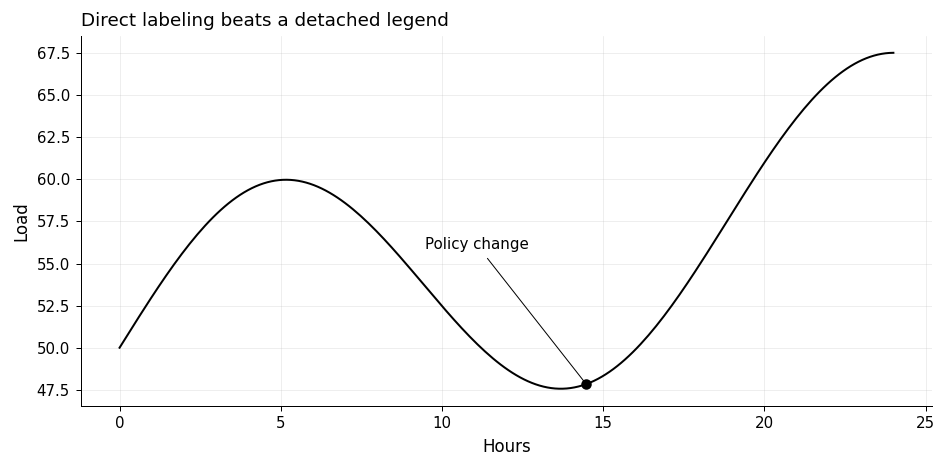

In [5]:
x = np.linspace(0, 24, 200)
y = 50 + 8 * np.sin(x / 3) + 0.4 * x
event_idx = 120

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
tufte_axes(ax, show_grid=True)
ax.plot(x, y, color="black", linewidth=1.2)

ax.scatter([x[event_idx]], [y[event_idx]], s=28, color="black", zorder=4)
ax.annotate(
    "Policy change",
    xy=(x[event_idx], y[event_idx]),
    xytext=(x[event_idx] - 5, y[event_idx] + 8),
    fontsize=9,
    arrowprops=dict(arrowstyle="-", linewidth=0.6, color="black"),
)
ax.set_xlabel("Hours")
ax.set_ylabel("Load")
ax.set_title("Direct labeling beats a detached legend", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Checklist (for your own plots)

- **Erase** heavy frames, 3D where it distorts, decorative gradients, and redundant ticks.
- **Prefer** thin baselines, restrained grids, and one strong visual channel for the main message.
- **Repeat** the same small chart across categories when comparing distributions over time or space.
- **Pair** tables with sparklines when the reader needs both exact values and shape.
- **Annotate** on the evidence; keep words, numbers, and graphics in the same visual field.

Tufte’s principles are guidelines for **clarity and honesty**, not a single matplotlib style—adapt them to your medium (print, slides, dashboards) while keeping the reader’s cognitive load low.